In [16]:
##
import pandas as pd
import matplotlib.pyplot as plt
#df= pd.read_csv("../datasets/processed/erc_20/processed_token_transfers.csv")

In [2]:
df.head()

,block_number,transaction_index,from_address,to_address,time_stamp,contract_address,value,date
0,14669683,7,0xd30b438df65f4f788563b2b3611bd6059bff4ad9,0xda816e2122a8a39b0926bfa84edd3d42477e9efd,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,18.670000,2022-04-28 00:30:15
1,14669683,45,0x4941834ed1428089ee76252f6f9d767e800499b0,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,10000.000000,2022-04-28 00:30:15
2,14669683,46,0x2c1f9a20711e14f8484a41123e20d1b06858ebea,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9942.313005,2022-04-28 00:30:15
3,14669683,47,0x7784c4f53aa5f03bd6d3ca670c9d9c887cc38cb0,0x3cd751e6b0078be393132286c442345e5dc49699,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,234.364097,2022-04-28 00:30:15
4,14669683,48,0x66589b8278470d58d4112f3d065de0f75734312e,0x28c6c06298d514db089934071355e5743bf21d60,1651105815,0xdac17f958d2ee523a2206206994597c13d831ec7,9800.000000,2022-04-28 00:30:15


In [ ]:
df.groupby(["block_number", "transaction_index"]).size()




block_number  transaction_index
14669683      1                    1
              7                    1
              9                    1
              33                   1
              45                   1
                                  ..
14843502      152                  1
              181                  1
              183                  1
14843503      2                    1
              4                    1
Length: 4468270, dtype: int64

In [8]:
actions = (
    df.groupby(["block_number", "transaction_index"])
      .agg(
          n_events=("value", "size"),
          total_value=("value", "sum"),
          unique_tokens=("contract_address", "nunique"),
          unique_receivers=("to_address", "nunique"),
          first_time=("date", "min")
      )
      .reset_index()
)

In [31]:
actions["first_time"] = pd.to_datetime(actions["first_time"])

collapse_time = pd.Timestamp("2022-05-09 12:00")  
start_time = collapse_time - pd.Timedelta(days=20)

subset = actions[
    (actions["first_time"] >= start_time) &
    (actions["first_time"] <= collapse_time)
].copy()


In [32]:
subset["hour"] = subset["first_time"].dt.floor("h")

hourly_counts = (
    subset.groupby("hour")
          .size()
          .rename("n_actions")
          .reset_index()
)
hourly_complexity = (
    subset.groupby("hour")["n_events"]
    
          .mean()
          .reset_index(name="avg_events_per_action")
)
hourly = hourly_counts.merge(hourly_complexity, on="hour", how="inner")
hourly = hourly.sort_values("hour")

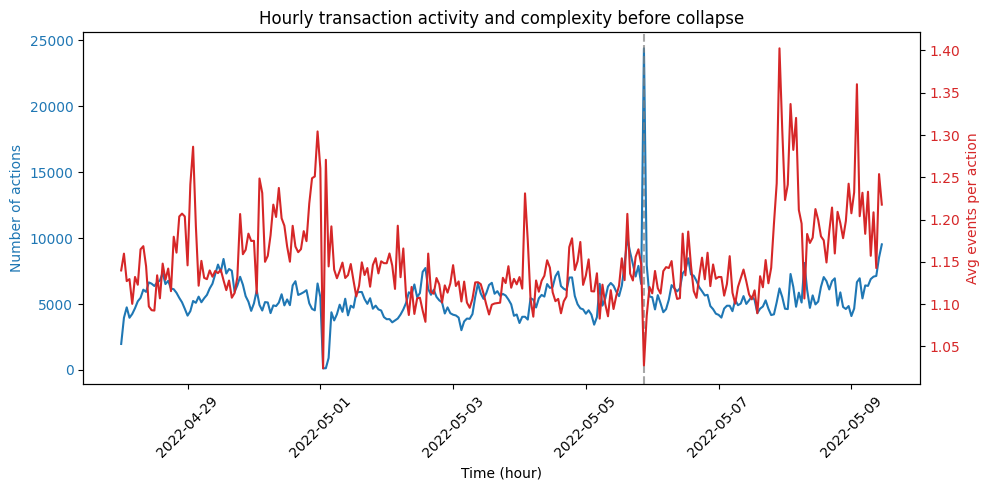

In [33]:
fig, ax1 = plt.subplots(figsize=(10, 5))

# Left axis: number of actions
ax1.plot(
    hourly["hour"],
    hourly["n_actions"],
    label="Number of actions",
    color="tab:blue"
)
ax1.set_xlabel("Time (hour)")
ax1.set_ylabel("Number of actions", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.tick_params(axis="x", rotation=45)

# Right axis: average events per action (complexity)
ax2 = ax1.twinx()
ax2.plot(
    hourly["hour"],
    hourly["avg_events_per_action"],
    label="Avg events per action",
    color="tab:red"
)
ax2.set_ylabel("Avg events per action", color="tab:red")
ax2.tick_params(axis="y", labelcolor="tab:red")

# Optional: mark peak hour
peak_hour = hourly.loc[hourly["n_actions"].idxmax(), "hour"]
ax1.axvline(peak_hour, linestyle="--", color="grey", alpha=0.7)

# Title and layout
plt.title("Hourly transaction activity and complexity before collapse")
fig.tight_layout()
plt.show()

In [ ]:
## exact max hour
peak_row = hourly_counts.loc[hourly_counts["n_actions"].idxmax()]
peak_time = peak_row["hour"]
peak_actions = int(peak_row["n_actions"])
peak_time, peak_actions

(Timestamp('2022-05-05 21:00:00'), 24384)